<center><h1> 2. Machine learning</h1></center>
<ol>
    <li>Hello</li>
    <li>Hello</li>
    <li>Hello</li>
    <li>Hello</li>
    <li>Hello</li>
</ol>

importing pandas

In [18]:
import pandas as pd
import numpy as np

In [19]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [20]:
df = pd.read_csv('data/marketing_campaign.csv',sep='\t')
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


## Data Preprocessing

In [21]:
# converted to boolean
df['Kidhome'] = df['Kidhome'].astype('bool')
df['Teenhome'] = df['Teenhome'].astype('bool')
df['AcceptedCmp1'] = df['AcceptedCmp1'].astype('bool')
df['AcceptedCmp2'] = df['AcceptedCmp2'].astype('bool')
df['AcceptedCmp3'] = df['AcceptedCmp3'].astype('bool')
df['AcceptedCmp4'] = df['AcceptedCmp4'].astype('bool')
df['AcceptedCmp5'] = df['AcceptedCmp5'].astype('bool')
df['Complain'] = df['Complain'].astype('bool')
df['Response'] = df['Response'].astype('bool')

# converted to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

# converted to int16
df['Year_Birth'] = df['Year_Birth'].astype('int16')
df['Recency'] = df['Recency'].astype('int16')
df['MntWines'] = df['MntWines'].astype('int16')
df['MntFruits'] = df['MntFruits'].astype('int16')
df['MntMeatProducts'] = df['MntMeatProducts'].astype('int16')
df['MntFishProducts'] = df['MntFishProducts'].astype('int16')
df['MntSweetProducts'] = df['MntSweetProducts'].astype('int16')
df['MntGoldProds'] = df['MntGoldProds'].astype('int16')
df['NumDealsPurchases'] = df['NumDealsPurchases'].astype('int16')
df['NumCatalogPurchases'] = df['NumCatalogPurchases'].astype('int16')
df['NumStorePurchases'] = df['NumStorePurchases'].astype('int16')
df['NumWebPurchases'] = df['NumWebPurchases'].astype('int16')
df['NumWebVisitsMonth'] = df['NumWebVisitsMonth'].astype('int16')

# converted to int8
df['Z_CostContact'] = df['Z_CostContact'].astype('int8')
df['Z_Revenue'] = df['Z_Revenue'].astype('int8')


### Feature engineering

In [22]:
df['month_enrolled'] = df['Dt_Customer'].dt.month
df['year_enrolled'] = df['Dt_Customer'].dt.year
df['age'] = df['year_enrolled'] - df['Year_Birth']

In [23]:
ref_date = df['Dt_Customer'].max()
ref_date

Timestamp('2014-06-29 00:00:00')

> [ **Note** - I used reference date from dataset to get accurate results. ]

In [24]:
df['months_since_enrolled'] = (ref_date - df['Dt_Customer']).dt.days // 30
df['months_since_enrolled']

0       22
1        3
2       10
3        4
4        5
5        9
6       19
7       13
8       12
9        3
10       7
11      19
12       7
13       7
14      20
15      19
16      18
17      22
18      15
19      20
20      23
21      17
22      18
23       5
24      15
25      18
26      13
27      16
28      13
29       7
30       1
31      13
32      20
33      20
34      16
35      10
36       6
37      10
38       4
39      17
40      14
41      15
42      18
43       7
44       9
45       0
46      19
47      13
48       5
49      19
50       1
51      22
52      18
53       0
54      12
55      19
56      15
57       2
58      12
59       3
60      12
61      22
62      16
63      12
64       6
65      13
66       1
67       3
68       9
69      14
70      21
71      21
72      15
73      15
74       2
75      18
76      22
77      20
78       9
79      18
80      22
81      12
82      12
83      13
84       4
85      10
86      11
87       1
88       1
89       5
90      19

### Importing data preprocessing libraries
Preparing X and Y variables

In [25]:
X = df.drop(columns=['ID','Dt_Customer','age','Z_CostContact','Z_Revenue','month_enrolled','year_enrolled','Response'])
y = df['Response']

In [26]:
(X.shape,y.shape)

((2240, 25), (2240,))

In [27]:
X.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,months_since_enrolled
0,1957,Graduation,Single,58138.0,False,False,58,635,88,546,172,88,88,3,8,10,4,7,False,False,False,False,False,False,22
1,1954,Graduation,Single,46344.0,True,True,38,11,1,6,2,1,6,2,1,1,2,5,False,False,False,False,False,False,3
2,1965,Graduation,Together,71613.0,False,False,26,426,49,127,111,21,42,1,8,2,10,4,False,False,False,False,False,False,10
3,1984,Graduation,Together,26646.0,True,False,26,11,4,20,10,3,5,2,2,0,4,6,False,False,False,False,False,False,4
4,1981,PhD,Married,58293.0,True,False,94,173,43,118,46,27,15,5,5,3,6,5,False,False,False,False,False,False,5


In [28]:
y.head()

0     True
1    False
2    False
3    False
4    False
Name: Response, dtype: bool

#### Splitting features

In [29]:
nominal_cols = ['Marital_Status']
ordinal_cols = ['Education']
numerical_cols = X.drop(columns=nominal_cols + ordinal_cols).columns.tolist()
print("Nominal columns:", nominal_cols)
print("Ordinal columns:", ordinal_cols)
print("Numerical columns:", numerical_cols)

Nominal columns: ['Marital_Status']
Ordinal columns: ['Education']
Numerical columns: ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'months_since_enrolled']


#### Tranforming and Scalling data

In [30]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [31]:
ordinal_transformer = OrdinalEncoder()
nominal_transformer = OneHotEncoder()
numerical_transformer = StandardScaler()

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', ordinal_transformer, ordinal_cols),
        ('nominal', nominal_transformer, nominal_cols),
        ('numerical', numerical_transformer, numerical_cols)
    ]
)
preprocessor

ColumnTransformer(transformers=[('ordinal', OrdinalEncoder(), ['Education']),
                                ('nominal', OneHotEncoder(),
                                 ['Marital_Status']),
                                ('numerical', StandardScaler(),
                                 ['Year_Birth', 'Income', 'Kidhome', 'Teenhome',
                                  'Recency', 'MntWines', 'MntFruits',
                                  'MntMeatProducts', 'MntFishProducts',
                                  'MntSweetProducts', 'MntGoldProds',
                                  'NumDealsPurchases', 'NumWebPurchases',
                                  'NumCatalogPurchases', 'NumStorePurchases',
                                  'NumWebVisitsMonth', 'AcceptedCmp3',
                                  'AcceptedCmp4', 'AcceptedCmp5',
                                  'AcceptedCmp1', 'AcceptedCmp2', 'Complain',
                                  'months_since_enrolled'])])

In [33]:
X.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,months_since_enrolled
0,1957,Graduation,Single,58138.0,False,False,58,635,88,546,172,88,88,3,8,10,4,7,False,False,False,False,False,False,22
1,1954,Graduation,Single,46344.0,True,True,38,11,1,6,2,1,6,2,1,1,2,5,False,False,False,False,False,False,3
2,1965,Graduation,Together,71613.0,False,False,26,426,49,127,111,21,42,1,8,2,10,4,False,False,False,False,False,False,10
3,1984,Graduation,Together,26646.0,True,False,26,11,4,20,10,3,5,2,2,0,4,6,False,False,False,False,False,False,4
4,1981,PhD,Married,58293.0,True,False,94,173,43,118,46,27,15,5,5,3,6,5,False,False,False,False,False,False,5


In [34]:
X = preprocessor.fit_transform(X)

In [38]:
X.shape

(2240, 32)

#### Spliting data into Training and Testing set

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1792, 32)
X_test shape: (448, 32)
y_train shape: (1792,)
y_test shape: (448,)


## Model Training

In [44]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [45]:
def evaluate_model(true_values, predictions):
    cr = classification_report(true_values, predictions)
    cm = confusion_matrix(true_values, predictions)
    accuracy = accuracy_score(true_values, predictions)
    return cr, cm, accuracy

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

In [49]:
models = {
    'LogisticRegression': LogisticRegression(),
    'RandomForestClassifier': RandomForestClassifier(),
    'SVR': SVC(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'AdaBoostClassifier': AdaBoostClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'VotingClassifier': VotingClassifier(estimators=[
        ('rf', RandomForestClassifier()),
        ('dt', DecisionTreeClassifier()),
        ('knn', KNeighborsClassifier())
    ]),
    'StackingClassifier': StackingClassifier(estimators=[
        ('rf', RandomForestClassifier()),
        ('dt', DecisionTreeClassifier()),
        ('knn', KNeighborsClassifier())
    ], final_estimator=LogisticRegression()),
    'XGBClassifier': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [57]:
accuracy_score_list = {}

In [87]:
from sklearn.impute import SimpleImputer

# Impute missing values in X_train and X_test
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_imputed, y_train)

    y_pred_train = model.predict(X_train_imputed)
    y_pred_test = model.predict(X_test_imputed)

    # Evaluating the train and test set
    model_cr_train, model_cm_train, model_acc_train = evaluate_model(y_train, y_pred_train)
    model_cr_test, model_cm_test, model_acc_test = evaluate_model(y_test, y_pred_test)

    model_name = list(models.keys())[i]
    print(f"Model: {model_name}")

    print('Model perfomance for train set')
    print(f'- Classification Report : \n {model_cr_train}')
    print(f'- Confusion Matrix : {model_cm_train}')
    print(f'- Accuracy Score : {model_acc_train}')

    print('--------------------------------------------')

    print('Model perfomance for test set')
    print(f'- Classification Report :\n {model_cr_test}')
    print(f'- Confusion Matrix : {model_cm_test}')
    print(f'- Accuracy Score : {model_acc_test}')

    accuracy_score_list[model_name] = model_acc_test

    print('='*35)
    print('\n')

Model: LogisticRegression
Model perfomance for train set
- Classification Report : 
               precision    recall  f1-score   support

       False       0.92      0.97      0.94      1527
        True       0.75      0.52      0.61       265

    accuracy                           0.90      1792
   macro avg       0.84      0.75      0.78      1792
weighted avg       0.90      0.90      0.90      1792

- Confusion Matrix : [[1481   46]
 [ 127  138]]
- Accuracy Score : 0.9034598214285714
--------------------------------------------
Model perfomance for test set
- Classification Report :
               precision    recall  f1-score   support

       False       0.89      0.97      0.92       379
        True       0.63      0.32      0.42        69

    accuracy                           0.87       448
   macro avg       0.76      0.64      0.67       448
weighted avg       0.85      0.87      0.85       448

- Confusion Matrix : [[366  13]
 [ 47  22]]
- Accuracy Score : 0.86607142

/home/aryan/miniconda3/envs/Machine_learning/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [11:28:42] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

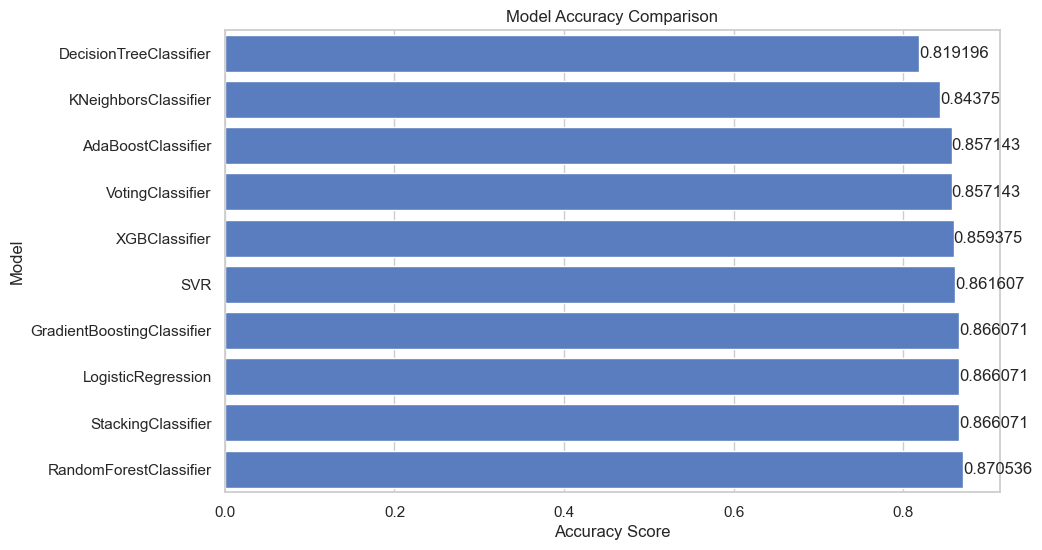

In [97]:
plt.figure(figsize=(10, 6))
model_names = list(accuracy_score_list.keys())
accuracies = list(accuracy_score_list.values())

# Sort models by accuracy
sorted_indices = np.argsort(accuracies)
sorted_model_names = [model_names[i] for i in sorted_indices]
sorted_accuracies = [accuracies[i] for i in sorted_indices]

sns.set_theme(style="whitegrid", palette="muted")
ax = sns.barplot(x=sorted_accuracies, y=sorted_model_names)
plt.bar_label(ax.containers[0])
plt.xlabel('Accuracy Score')
plt.ylabel('Model')
plt.title('Model Accuracy Comparison')
plt.show()


## Random Forest

In [104]:
def tune_random_forest(X_train, X_test, y_train, y_test):
    param_results = {}
    
    # List of parameters to test
    max_depths = [5, 10, 15, 20]
    n_estimators = [50, 100, 200]
    min_samples_splits = [2, 5, 10]
    
    best_accuracy = 0
    
    for depth in max_depths:
        for n_est in n_estimators:
            for min_split in min_samples_splits:
                # Create and train model
                rf = RandomForestClassifier(
                    max_depth=depth,
                    n_estimators=n_est,
                    min_samples_split=min_split,
                    random_state=42
                )
                
                rf.fit(X_train, y_train)
                accuracy = rf.score(X_test, y_test)
                
                # Store parameters and results
                params = {
                    'max_depth': depth,
                    'n_estimators': n_est,
                    'min_samples_split': min_split
                }
                
                key = f"rf_depth{depth}_est{n_est}_split{min_split}"
                param_results[key] = {
                    'params': params,
                    'accuracy': accuracy,
                    'model_name': 'RandomForestClassifier'
                }
                
                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    best_params = params
    
    return param_results, best_params, best_accuracy

In [105]:
print("Tuning Random Forest Classifier...")
rf_param_results, best_rf_params, best_rf_accuracy = tune_random_forest(X_train_imputed, X_test_imputed, y_train, y_test)
print("Best Random Forest Parameters:", best_rf_params)
print("Best Random Forest Accuracy:", best_rf_accuracy)
# Displaying the results of the tuning
rf_results_df = pd.DataFrame.from_dict(rf_param_results, orient='index')
rf_results_df = rf_results_df.sort_values(by='accuracy', ascending=False)
print("Random Forest Parameter Tuning Results:")
print(rf_results_df)

Tuning Random Forest Classifier...
Best Random Forest Parameters: {'max_depth': 15, 'n_estimators': 200, 'min_samples_split': 5}
Best Random Forest Accuracy: 0.8794642857142857
Random Forest Parameter Tuning Results:
                                                                      params  \
rf_depth15_est200_split5   {'max_depth': 15, 'n_estimators': 200, 'min_sa...   
rf_depth20_est200_split5   {'max_depth': 20, 'n_estimators': 200, 'min_sa...   
rf_depth20_est50_split2    {'max_depth': 20, 'n_estimators': 50, 'min_sam...   
rf_depth15_est100_split2   {'max_depth': 15, 'n_estimators': 100, 'min_sa...   
rf_depth15_est100_split5   {'max_depth': 15, 'n_estimators': 100, 'min_sa...   
rf_depth20_est100_split10  {'max_depth': 20, 'n_estimators': 100, 'min_sa...   
rf_depth15_est200_split2   {'max_depth': 15, 'n_estimators': 200, 'min_sa...   
rf_depth20_est50_split10   {'max_depth': 20, 'n_estimators': 50, 'min_sam...   
rf_depth10_est50_split5    {'max_depth': 10, 'n_estimators': 50

In [108]:
random_forest = RandomForestClassifier(max_depth=15, n_estimators=200, min_samples_split=5, random_state=42)
random_forest.fit(X_train, y_train)
y_pred = random_forest.predict(X_test)
score = random_forest.score(X_test, y_test)
print(f"Model Accuracy: {score}")

Model Accuracy: 0.8794642857142857


<center>Hello</center>